# 4-Class Defect Detection — MobileNetV2 (Phase 1 + Fine-Tuning)

This notebook trains a **single MobileNetV2** model to classify images into **4 classes**:

| Label | Class | Images | Source folder |
|-------|-------|--------|---------------|
| 0 | Cracking | 1,663 | `data/Cracking` |
| 1 | Stringing | 2,555 | `data/Stringing` |
| 2 | Warping | 1,707 | `data/Warping` |
| 3 | No_Defect | 1,811 | `data/No_Stringing` |

**Training in 2 phases:**
- **Phase 1** — MobileNetV2 base fully frozen, only head trained, `lr = 1e-4`
- **Phase 2 (fine-tuning)** — Last 20 layers of MobileNetV2 unfrozen, `lr = 1e-5`

**Loss:** `categorical_crossentropy` | **Output:** `Dense(4, softmax)`

---
## 1. Imports & Configuration

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)

SEED        = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 50
NUM_CLASSES = 4

CLASS_NAMES = ["Cracking", "Stringing", "Warping", "No_Defect"]

print(f"TensorFlow: {tf.__version__}")
print(f"GPU       : {tf.config.list_physical_devices('GPU')}")

2026-05-14 23:13:49.124850: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778796829.223910    1259 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778796829.252438    1259 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-14 23:13:49.482385: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.18.0
GPU       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 2. Load & Split the Dataset

`No_Stringing` is used as the **No_Defect** class (label 3).  
Split: **80 % train / 10 % val / 10 % test**, shuffled with fixed seed.

In [3]:
BASE     = os.getcwd()   # Defect-Detection/
DATA_DIR = os.path.join(BASE, "data")

# (folder_name, label_index)
CLASS_FOLDERS = [
    ("Cracking",    0),
    ("Stringing",   1),
    ("Warping",     2),
    ("No_Stringing",3),   # used as No_Defect
]

all_paths, all_labels = [], []
for folder, label in CLASS_FOLDERS:
    d = os.path.join(DATA_DIR, folder)
    imgs = [os.path.join(d, f) for f in os.listdir(d) if f.endswith(".jpg")]
    all_paths.extend(imgs)
    all_labels.extend([label] * len(imgs))
    display = CLASS_NAMES[label]
    print(f"  {display:<12} (label={label}): {len(imgs)} images")

print(f"\nTotal: {len(all_paths)} images")

# Shuffle
rng = np.random.default_rng(SEED)
idx = rng.permutation(len(all_paths))
all_paths  = np.array(all_paths)[idx]
all_labels = np.array(all_labels)[idx]

# 80 / 10 / 10
n       = len(all_paths)
n_train = int(n * 0.80)
n_val   = int(n * 0.10)

train_paths,  train_labels = all_paths[:n_train],               all_labels[:n_train]
val_paths,    val_labels   = all_paths[n_train:n_train+n_val],  all_labels[n_train:n_train+n_val]
test_paths,   test_labels  = all_paths[n_train+n_val:],         all_labels[n_train+n_val:]

print(f"\nTrain : {len(train_paths)}")
print(f"Val   : {len(val_paths)}")
print(f"Test  : {len(test_labels)}")

  Cracking     (label=0): 1663 images
  Stringing    (label=1): 2555 images
  Warping      (label=2): 1707 images
  No_Defect    (label=3): 1811 images

Total: 7736 images

Train : 6188
Val   : 773
Test  : 775


---
## 3. Build tf.data Pipelines

- Resize to **224 × 224**, normalize to **[0, 1]**
- Labels **one-hot encoded** (required for `categorical_crossentropy`)
- Augmentation on training only: random flip, brightness ±20%, rotation ±20°

In [4]:
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

# Instantiated once outside augment to avoid tf.function Variable error
_random_rotation = tf.keras.layers.RandomRotation(0.056)

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.clip_by_value(img, 0.0, 1.0)
    img = _random_rotation(img, training=True)
    return img, label

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .shuffle(1000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("✅ Datasets ready.")

I0000 00:00:1778796832.865057    1259 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


✅ Datasets ready.


---
## 4. Build the Model

MobileNetV2 base (ImageNet weights, **fully frozen**) + custom head:  
`GlobalAvgPool → Dense(256, ReLU) → Dropout(0.3) → Dense(4, softmax)`

In [5]:
base_model = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

print(f"Base model layers : {len(base_model.layers)}")
print(f"Trainable weights : {len(base_model.trainable_weights)}")

inputs  = keras.Input(shape=(*IMG_SIZE, 3), name="input_image")
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x       = layers.Dense(256, activation="relu", name="dense_256")(x)
x       = layers.Dropout(0.3, name="dropout_03")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="output")(x)

model = keras.Model(inputs, outputs, name="MobileNetV2_4Class")
model.summary()

Base model layers : 154
Trainable weights : 0


Model: "MobileNetV2_4Class"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_03 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

---
## 5. Compile — Phase 1 (Frozen Base)

- **Optimizer:** Adam, `lr = 1e-4`
- **Loss:** `categorical_crossentropy`

In [6]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
print("✅ Model compiled (Phase 1).")

✅ Model compiled (Phase 1).


---
## 6. Train — Phase 1

In [6]:
BEST_P1 = "best_mobilenetv2_4class_phase1.h5"

In [7]:
BEST_P1 = "best_mobilenetv2_4class_phase1.h5"

cb_p1 = [
    callbacks.EarlyStopping(monitor="val_loss", patience=10,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=5, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint(filepath=BEST_P1, monitor="val_loss",
                              save_best_only=True, verbose=1),
]

history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb_p1,
)
print("\n✅ Phase 1 complete.")

Epoch 1/50


I0000 00:00:1778792491.275106   15234 service.cc:148] XLA service 0x7e1bb01108d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778792491.275874   15234 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2060 SUPER, Compute Capability 7.5
2026-05-14 22:01:31.563742: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778792492.448188   15234 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/194 ━━━━━━━━━━━━━━━━━━━━ 59:57 19s/step - accuracy: 0.2812 - loss: 1.5425

I0000 00:00:1778792497.800810   15234 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.6876 - loss: 0.7650
Epoch 1: val_loss improved from None to 0.28206, saving model to best_mobilenetv2_4class_phase1.h5


...


Epoch 24: finished saving model to best_mobilenetv2_4class_phase1.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 49s 215ms/step - accuracy: 0.9577 - loss: 0.1019 - val_accuracy: 0.9418 - val_loss: 0.1150 - learning_rate: 5.0000e-05
Epoch 25/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9592 - loss: 0.1016
Epoch 25: val_loss did not improve from 0.11500
194/194 ━━━━━━━━━━━━━━━━━━━━ 44s 193ms/step - accuracy: 0.9602 - loss: 0.0992 - val_accuracy: 0.9392 - val_loss: 0.1231 - learning_rate: 5.0000e-05
Epoch 26/50
192/194 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9613 - loss: 0.0954
Epoch 26: val_loss did not improve from 0.11500
194/194 ━━━━━━━━━━━━━━━━━━━━ 45s 191ms/step - accuracy: 0.9614 - loss: 0.0960 - val_accuracy: 0.9366 - val_loss: 0.1268 - learning_rate: 5.0000e-05
Epoch 27/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.9632 - loss: 0.0916
Epoch 27: val_loss did not improve from 0.11500
194/194 ━━━━━━━━━━━━━━━━━━━━ 48s 208ms/step - accuracy: 0.9599 - loss: 0.09


Epoch 28: finished saving model to best_mobilenetv2_4class_phase1.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 45s 194ms/step - accuracy: 0.9638 - loss: 0.0926 - val_accuracy: 0.9547 - val_loss: 0.1037 - learning_rate: 5.0000e-05
Epoch 29/50
192/194 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.9633 - loss: 0.0903
Epoch 29: val_loss did not improve from 0.10370
194/194 ━━━━━━━━━━━━━━━━━━━━ 47s 202ms/step - accuracy: 0.9590 - loss: 0.0972 - val_accuracy: 0.9547 - val_loss: 0.1183 - learning_rate: 5.0000e-05
Epoch 30/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9642 - loss: 0.0917
Epoch 30: val_loss did not improve from 0.10370
194/194 ━━━━━━━━━━━━━━━━━━━━ 44s 189ms/step - accuracy: 0.9664 - loss: 0.0899 - val_accuracy: 0.9560 - val_loss: 0.1067 - learning_rate: 5.0000e-05
Epoch 31/50
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.9631 - loss: 0.0874
Epoch 31: val_loss did not improve from 0.10370
194/194 ━━━━━━━━━━━━━━━━━━━━ 47s 202ms/step - accuracy: 0.9609 - loss: 0.09


Epoch 36: finished saving model to best_mobilenetv2_4class_phase1.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 46s 201ms/step - accuracy: 0.9651 - loss: 0.0864 - val_accuracy: 0.9599 - val_loss: 0.0999 - learning_rate: 2.5000e-05
Epoch 37/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.9676 - loss: 0.0870
Epoch 37: val_loss did not improve from 0.09991
194/194 ━━━━━━━━━━━━━━━━━━━━ 44s 189ms/step - accuracy: 0.9677 - loss: 0.0871 - val_accuracy: 0.9599 - val_loss: 0.1003 - learning_rate: 2.5000e-05
Epoch 38/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.9719 - loss: 0.0818
Epoch 38: val_loss improved from 0.09991 to 0.09879, saving model to best_mobilenetv2_4class_phase1.h5



Epoch 38: finished saving model to best_mobilenetv2_4class_phase1.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 47s 205ms/step - accuracy: 0.9665 - loss: 0.0849 - val_accuracy: 0.9599 - val_loss: 0.0988 - learning_rate: 2.5000e-05
Epoch 39/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9696 - loss: 0.0810
Epoch 39: val_loss did not improve from 0.09879
194/194 ━━━━━━━━━━━━━━━━━━━━ 45s 190ms/step - accuracy: 0.9675 - loss: 0.0844 - val_accuracy: 0.9483 - val_loss: 0.1059 - learning_rate: 2.5000e-05
Epoch 40/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.9708 - loss: 0.0800
Epoch 40: val_loss did not improve from 0.09879
194/194 ━━━━━━━━━━━━━━━━━━━━ 46s 200ms/step - accuracy: 0.9688 - loss: 0.0808 - val_accuracy: 0.9586 - val_loss: 0.1042 - learning_rate: 2.5000e-05
Epoch 41/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9670 - loss: 0.0841
Epoch 41: val_loss did not improve from 0.09879
194/194 ━━━━━━━━━━━━━━━━━━━━ 45s 190ms/step - accuracy: 0.9662 - loss: 0.08


Epoch 47: finished saving model to best_mobilenetv2_4class_phase1.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 47s 203ms/step - accuracy: 0.9669 - loss: 0.0804 - val_accuracy: 0.9547 - val_loss: 0.0979 - learning_rate: 1.2500e-05
Epoch 48/50
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.9675 - loss: 0.0812
Epoch 48: val_loss did not improve from 0.09793
194/194 ━━━━━━━━━━━━━━━━━━━━ 44s 199ms/step - accuracy: 0.9672 - loss: 0.0809 - val_accuracy: 0.9534 - val_loss: 0.1026 - learning_rate: 1.2500e-05
Epoch 49/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.9736 - loss: 0.0779
Epoch 49: val_loss did not improve from 0.09793
194/194 ━━━━━━━━━━━━━━━━━━━━ 46s 200ms/step - accuracy: 0.9720 - loss: 0.0789 - val_accuracy: 0.9508 - val_loss: 0.1018 - learning_rate: 1.2500e-05
Epoch 50/50
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.9714 - loss: 0.0752
Epoch 50: val_loss did not improve from 0.09793
194/194 ━━━━━━━━━━━━━━━━━━━━ 44s 199ms/step - accuracy: 0.9701 - loss: 0.07

---
## 7. Training History — Phase 1

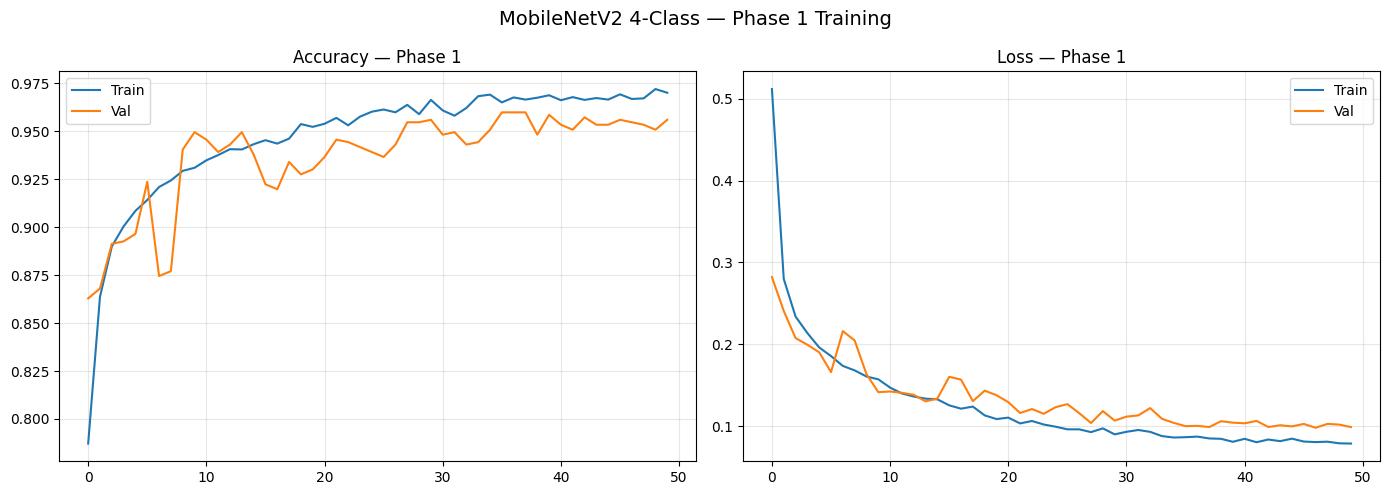

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_p1.history["accuracy"],    label="Train")
axes[0].plot(history_p1.history["val_accuracy"], label="Val")
axes[0].set_title("Accuracy — Phase 1"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history_p1.history["loss"],    label="Train")
axes[1].plot(history_p1.history["val_loss"], label="Val")
axes[1].set_title("Loss — Phase 1"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle("MobileNetV2 4-Class — Phase 1 Training", fontsize=14)
plt.tight_layout(); plt.show()

---
## 8. Fine-Tuning — Unfreeze Last 20 Layers

Load the Phase-1 best checkpoint, unfreeze the **last 20 layers** of the MobileNetV2 base,  
and recompile with `lr = 1e-5` (10× lower than Phase 1).

In [7]:
# Load best Phase-1 model
ft_model = keras.models.load_model(BEST_P1)
print("✅ Phase-1 best model loaded.")

# Unfreeze last 20 layers of the base
base = ft_model.get_layer("mobilenetv2_1.00_224")
base.trainable = True
for layer in base.layers[:-20]:
    layer.trainable = False

total    = len(base.layers)
frozen   = sum(not l.trainable for l in base.layers)
unfrozen = sum(l.trainable     for l in base.layers)
print(f"Base layers total : {total}")
print(f"  Frozen          : {frozen}")
print(f"  Unfrozen (last 20): {unfrozen}")

✅ Phase-1 best model loaded.
Base layers total : 154
  Frozen          : 134
  Unfrozen (last 20): 20


---
## 9. Compile — Fine-Tuning Phase (`lr = 1e-5`)

In [8]:
ft_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
print("✅ Model recompiled — lr = 1e-5")

✅ Model recompiled — lr = 1e-5


---
## 10. Train — Fine-Tuning Phase

In [9]:
BEST_FT = "best_mobilenetv2_4class_finetuned.h5"

cb_ft = [
    callbacks.EarlyStopping(monitor="val_loss", patience=10,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=5, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint(filepath=BEST_FT, monitor="val_loss",
                              save_best_only=True, verbose=1),
]

history_ft = ft_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb_ft,
)
print("\n✅ Fine-tuning complete.")

Epoch 1/50


I0000 00:00:1778796931.412291    1604 service.cc:148] XLA service 0x7e4190002ce0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778796931.412672    1604 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2060 SUPER, Compute Capability 7.5
2026-05-14 23:15:31.644840: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778796932.556643    1604 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/194 ━━━━━━━━━━━━━━━━━━━━ 17s 93ms/step - accuracy: 0.8672 - loss: 0.3732   

I0000 00:00:1778796937.203766    1604 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.8955 - loss: 0.2439
Epoch 1: val_loss improved from None to 0.12757, saving model to best_mobilenetv2_4class_finetuned.h5


...


Epoch 30: finished saving model to best_mobilenetv2_4class_finetuned.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 46s 201ms/step - accuracy: 0.9927 - loss: 0.0200 - val_accuracy: 0.9897 - val_loss: 0.0324 - learning_rate: 5.0000e-06
Epoch 31/50
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9923 - loss: 0.0240
Epoch 31: val_loss did not improve from 0.03237
194/194 ━━━━━━━━━━━━━━━━━━━━ 47s 206ms/step - accuracy: 0.9922 - loss: 0.0237 - val_accuracy: 0.9858 - val_loss: 0.0402 - learning_rate: 5.0000e-06
Epoch 32/50
192/194 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.9924 - loss: 0.0210
Epoch 32: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.

Epoch 32: val_loss did not improve from 0.03237
194/194 ━━━━━━━━━━━━━━━━━━━━ 46s 199ms/step - accuracy: 0.9924 - loss: 0.0217 - val_accuracy: 0.9767 - val_loss: 0.0508 - learning_rate: 5.0000e-06
Epoch 33/50
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9927 - loss: 0.0208
Epoch 33: val_loss did not improve from 0.


Epoch 36: finished saving model to best_mobilenetv2_4class_finetuned.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 48s 208ms/step - accuracy: 0.9926 - loss: 0.0204 - val_accuracy: 0.9871 - val_loss: 0.0300 - learning_rate: 2.5000e-06
Epoch 37/50
192/194 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9919 - loss: 0.0221
Epoch 37: val_loss did not improve from 0.03000
194/194 ━━━━━━━━━━━━━━━━━━━━ 48s 207ms/step - accuracy: 0.9926 - loss: 0.0211 - val_accuracy: 0.9871 - val_loss: 0.0311 - learning_rate: 2.5000e-06
Epoch 38/50
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.9941 - loss: 0.0175
Epoch 38: val_loss did not improve from 0.03000
194/194 ━━━━━━━━━━━━━━━━━━━━ 45s 199ms/step - accuracy: 0.9935 - loss: 0.0200 - val_accuracy: 0.9871 - val_loss: 0.0305 - learning_rate: 2.5000e-06
Epoch 39/50
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9936 - loss: 0.0214
Epoch 39: val_loss did not improve from 0.03000
194/194 ━━━━━━━━━━━━━━━━━━━━ 45s 206ms/step - accuracy: 0.9937 - loss: 0


Epoch 40: finished saving model to best_mobilenetv2_4class_finetuned.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 48s 206ms/step - accuracy: 0.9927 - loss: 0.0201 - val_accuracy: 0.9909 - val_loss: 0.0285 - learning_rate: 2.5000e-06
Epoch 41/50
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9925 - loss: 0.0221
Epoch 41: val_loss improved from 0.02849 to 0.02816, saving model to best_mobilenetv2_4class_finetuned.h5



Epoch 41: finished saving model to best_mobilenetv2_4class_finetuned.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 46s 207ms/step - accuracy: 0.9921 - loss: 0.0218 - val_accuracy: 0.9884 - val_loss: 0.0282 - learning_rate: 2.5000e-06
Epoch 42/50
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.9918 - loss: 0.0202
Epoch 42: val_loss did not improve from 0.02816
194/194 ━━━━━━━━━━━━━━━━━━━━ 45s 195ms/step - accuracy: 0.9935 - loss: 0.0191 - val_accuracy: 0.9871 - val_loss: 0.0346 - learning_rate: 2.5000e-06
Epoch 43/50
192/194 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.9942 - loss: 0.0170
Epoch 43: val_loss did not improve from 0.02816
194/194 ━━━━━━━━━━━━━━━━━━━━ 47s 206ms/step - accuracy: 0.9937 - loss: 0.0177 - val_accuracy: 0.9858 - val_loss: 0.0291 - learning_rate: 2.5000e-06
Epoch 44/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.9945 - loss: 0.0165
Epoch 44: val_loss did not improve from 0.02816
194/194 ━━━━━━━━━━━━━━━━━━━━ 47s 203ms/step - accuracy: 0.9943 - loss: 0


Epoch 46: finished saving model to best_mobilenetv2_4class_finetuned.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 48s 208ms/step - accuracy: 0.9932 - loss: 0.0186 - val_accuracy: 0.9871 - val_loss: 0.0260 - learning_rate: 2.5000e-06
Epoch 47/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.9949 - loss: 0.0157
Epoch 47: val_loss did not improve from 0.02599
194/194 ━━━━━━━━━━━━━━━━━━━━ 47s 207ms/step - accuracy: 0.9939 - loss: 0.0169 - val_accuracy: 0.9858 - val_loss: 0.0328 - learning_rate: 2.5000e-06
Epoch 48/50
192/194 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9940 - loss: 0.0166
Epoch 48: val_loss did not improve from 0.02599
194/194 ━━━━━━━━━━━━━━━━━━━━ 45s 197ms/step - accuracy: 0.9948 - loss: 0.0174 - val_accuracy: 0.9871 - val_loss: 0.0348 - learning_rate: 2.5000e-06
Epoch 49/50
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.9953 - loss: 0.0170
Epoch 49: val_loss did not improve from 0.02599
194/194 ━━━━━━━━━━━━━━━━━━━━ 48s 206ms/step - accuracy: 0.9945 - loss: 0

---
## 11. Training History — Fine-Tuning Phase

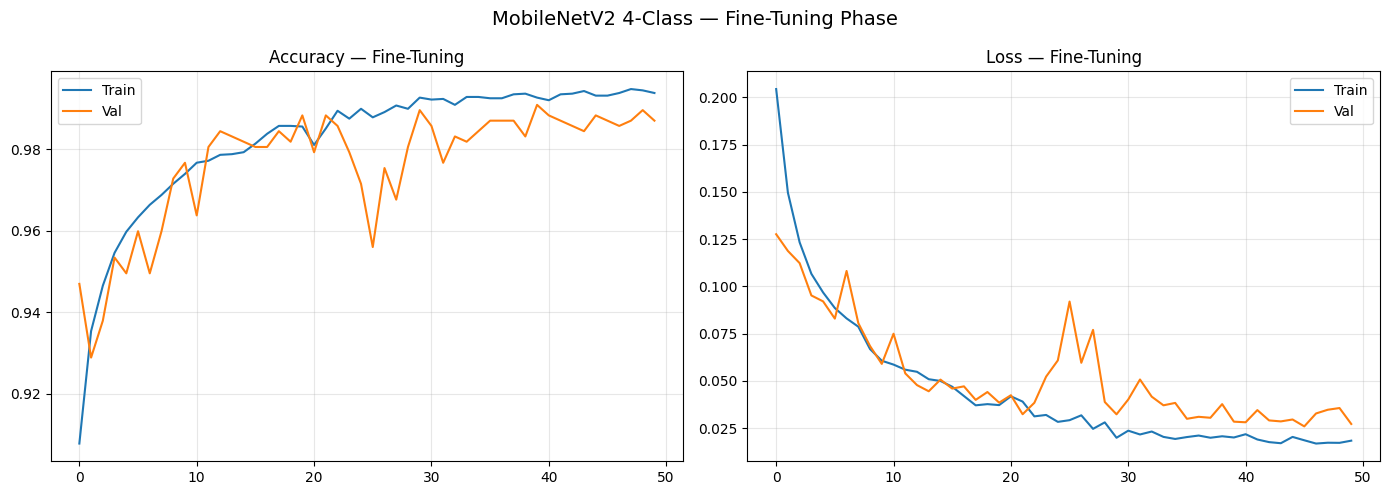

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_ft.history["accuracy"],    label="Train")
axes[0].plot(history_ft.history["val_accuracy"], label="Val")
axes[0].set_title("Accuracy — Fine-Tuning"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history_ft.history["loss"],    label="Train")
axes[1].plot(history_ft.history["val_loss"], label="Val")
axes[1].set_title("Loss — Fine-Tuning"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle("MobileNetV2 4-Class — Fine-Tuning Phase", fontsize=14)
plt.tight_layout(); plt.show()

---
## 12. Evaluate on Test Set

In [11]:
best_model = keras.models.load_model(BEST_FT)

y_pred_probs = best_model.predict(test_ds, verbose=1)      # (N, 4)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_labels

acc = accuracy_score(y_true, y_pred)
print(f"\nTest Accuracy: {acc:.4f}  ({acc*100:.2f}%)\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 272ms/step

Test Accuracy: 0.9923  (99.23%)

              precision    recall  f1-score   support

    Cracking       1.00      1.00      1.00       173
   Stringing       0.99      0.98      0.99       243
     Warping       1.00      1.00      1.00       169
   No_Defect       0.98      0.99      0.98       190

    accuracy                           0.99       775
   macro avg       0.99      0.99      0.99       775
weighted avg       0.99      0.99      0.99       775



---
## 13. Confusion Matrix

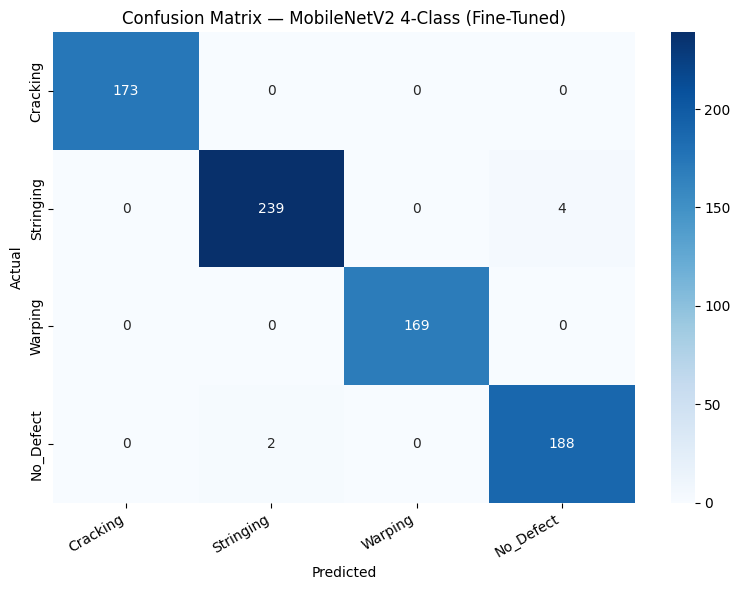

In [12]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — MobileNetV2 4-Class (Fine-Tuned)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

---
## 14. Save the Model

In [13]:
best_model.save("mobilenetv2_4class_final.h5")
best_model.save("mobilenetv2_4class_savedmodel")
print("✅ mobilenetv2_4class_final.h5")
print("✅ mobilenetv2_4class_savedmodel/")

ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=mobilenetv2_4class_savedmodel.